In [1]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu130
0.25.0+cu130


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [3]:
from captum.attr import IntegratedGradients # 통합 그래디언트(Integrated Gradients) 기법 임포트
from captum.attr import Saliency        # 살리언시 맵(Saliency) 기법 임포트
from captum.attr import DeepLift        # DeepLIFT 기법 임포트
from captum.attr import visualization as viz # 어트리뷰션 결과 시각화를 위한 유틸리티 임포트

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
np.random.seed(123)
torch.manual_seed(123)

In [58]:
import torchvision.models as models
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [125]:
transform = v2.Compose([
    v2.Resize((224,224)),
    # v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


torch.Size([3, 224, 224])

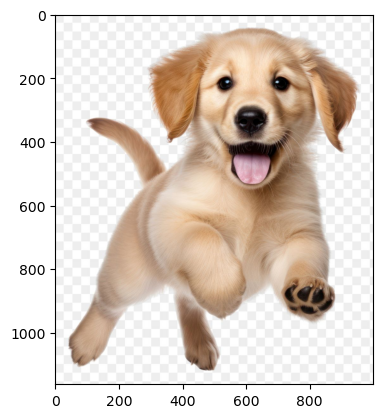

In [126]:
from PIL import Image
image_path = '/home/kim/Desktop/AI_cours/data/puppy.jpg'
# image_path = '/home/kim/Downloads/dog.png'
img = Image.open(image_path).convert('RGB')
plt.imshow(img)

img = transform(img)
img.shape

In [101]:
target = model(img.unsqueeze(0))

In [102]:
target.shape

torch.Size([1, 1000])

In [97]:
_, target_idx = torch.max(target,1)
target_idx

tensor([207])

In [98]:
captum_input = img.unsqueeze(0)

In [77]:
captum_input.shape

torch.Size([1, 3, 224, 224])

In [78]:
img[None,...].shape

torch.Size([1, 3, 224, 224])

In [79]:
captum_input.requires_grad = True

In [117]:
saliency = Saliency(model) # 쉽게 말해, "모델이 결과값을 내놓을 때 어떤 입력 피처(이미지 픽셀, 단어 등)에 가장 민감하게 반응했는가?"를 시각화해 주는 도구
gradients = saliency.attribute(captum_input, target=target_idx.item())
gradients = gradients.squeeze().cpu().detach().numpy()

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


In [118]:
gradients = np.sum(gradients,0)
gradients[...,None].shape

(224, 224, 1)

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


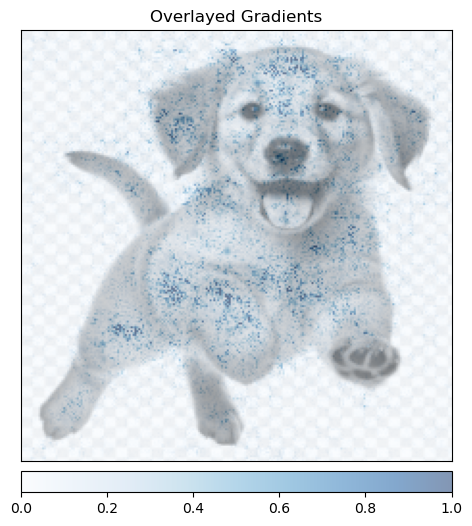

In [119]:
saliency = Saliency(model) # 쉽게 말해, "모델이 결과값을 내놓을 때 어떤 입력 피처(이미지 픽셀, 단어 등)에 가장 민감하게 반응했는가?"를 시각화해 주는 도구
gradients = saliency.attribute(captum_input, target=target_idx.item())
gradients = gradients.squeeze().cpu().detach().numpy()
gradients = np.sum(gradients,0)[...,None]
img_hwc = np.transpose(img.cpu().detach().numpy(), (1,2,0))
_ = viz.visualize_image_attr(gradients, img_hwc, method="blended_heat_map", sign="absolute_value",
                             show_colorbar=True, title="Overlayed Gradients")

In [81]:
np.transpose(gradients, (1,2,0)).shape

(224, 224, 3)

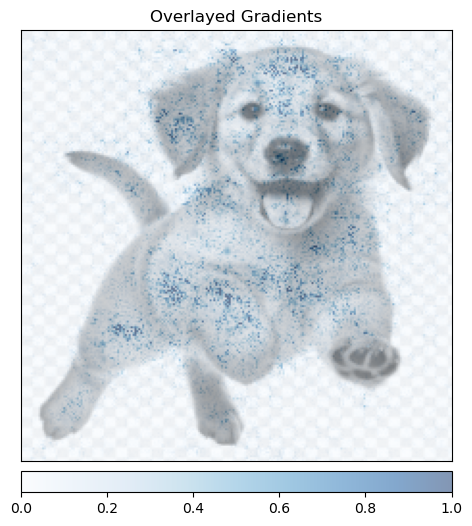

In [104]:
gradients_hwc = np.transpose(gradients, (1,2,0))
img_hwc = np.transpose(img.cpu().detach().numpy(), (1,2,0))
_ = viz.visualize_image_attr(gradients_hwc, img_hwc, method="blended_heat_map", sign="absolute_value",
                             show_colorbar=True, title="Overlayed Gradients")

In [84]:
target_idx

tensor([207])

In [86]:
integ_grads = IntegratedGradients(model)
attributed_ig, delta = integ_grads.attribute(
    captum_input,                      # 분석할 입력 데이터
    target=target_idx.item(),   # 타겟 클래스 인덱스 (모델이 예측한 클래스)
    baselines=captum_input * 0,        # 기준선(Baseline) 설정: 모든 픽셀 값을 0으로 설정한 이미지 (흑백 이미지의 경우 일반적)
    return_convergence_delta=True      # 수렴 델타 값 (오차)을 반환하도록 설정 (IG의 품질 확인 용도)
)

attributed_ig = attributed_ig.squeeze().cpu().detach().numpy()
attributed_ig = np.transpose(attributed_ig, (1,2,0))

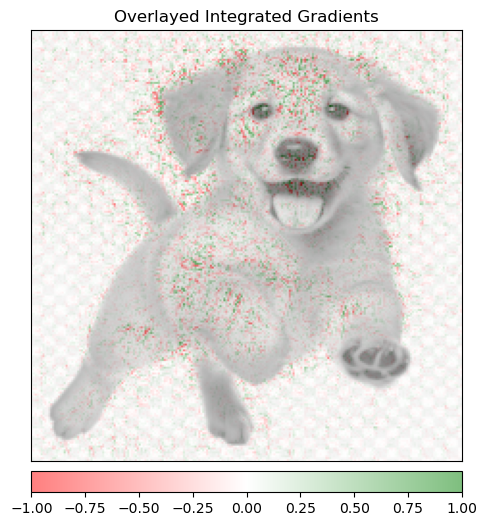

In [87]:
_ = viz.visualize_image_attr(attributed_ig, img_hwc, method="blended_heat_map",sign="all", show_colorbar=True,
                             title="Overlayed Integrated Gradients")

In [129]:
from captum.attr import LayerGradCam

# 모델과 타겟 레이어 설정 (예: ResNet의 layer4)
gc = LayerGradCam(model, model.layer4)

In [127]:
img

tensor([[[1.9578, 1.9578, 1.9578,  ..., 2.1633, 1.9578, 1.9578],
         [1.9578, 1.9578, 1.9578,  ..., 2.1633, 1.9578, 1.9578],
         [1.9578, 1.9578, 1.9578,  ..., 2.1633, 1.9578, 1.9578],
         ...,
         [2.2489, 2.2489, 2.2489,  ..., 2.0263, 2.2318, 2.2489],
         [2.0777, 2.0777, 2.0777,  ..., 2.0948, 2.0777, 2.0777],
         [1.9578, 1.9578, 1.9578,  ..., 2.1633, 1.9578, 1.9578]],

        [[2.1310, 2.1310, 2.1310,  ..., 2.3410, 2.1310, 2.1310],
         [2.1310, 2.1310, 2.1310,  ..., 2.3410, 2.1310, 2.1310],
         [2.1310, 2.1310, 2.1310,  ..., 2.3410, 2.1310, 2.1310],
         ...,
         [2.4286, 2.4286, 2.4286,  ..., 2.2010, 2.4111, 2.4286],
         [2.2535, 2.2535, 2.2535,  ..., 2.2710, 2.2535, 2.2535],
         [2.1310, 2.1310, 2.1310,  ..., 2.3410, 2.1310, 2.1310]],

        [[2.3437, 2.3437, 2.3437,  ..., 2.5529, 2.3437, 2.3437],
         [2.3437, 2.3437, 2.3437,  ..., 2.5529, 2.3437, 2.3437],
         [2.3437, 2.3437, 2.3437,  ..., 2.5529, 2.3437, 2.

In [134]:
img.unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [138]:
np.transpose(img, (1,2,0)).shape

torch.Size([224, 224, 3])

In [135]:
# target: 시각화할 클래스의 인덱스
# input_tensor: 전처리된 이미지 배치
attributions = gc.attribute(img.unsqueeze(0), target=target_idx.item())

TypeError: max() received an invalid combination of arguments - got (out=NoneType, axis=NoneType, ), but expected one of:
 * ()
 * (Tensor other)
 * (int dim, bool keepdim = False)
      didn't match because some of the keywords were incorrect: out, axis
 * (name dim, bool keepdim = False)
      didn't match because some of the keywords were incorrect: out, axis


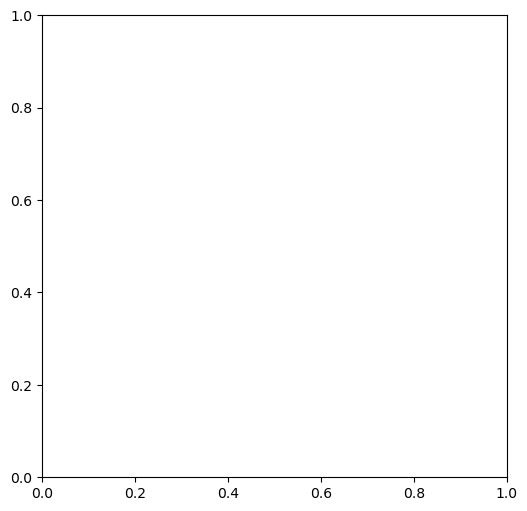

In [139]:
from captum.attr import visualization as viz
import numpy as np

# [C, H, W] -> [H, W, C]로 변환 및 numpy 변환
upsampled_attr = LayerGradCam.interpolate(attributions, (224, 224)) # 원본 크기 업샘플링
attr_np = upsampled_attr.squeeze().cpu().detach().numpy()
attr_np = np.transpose(attr_np, (1, 2, 0)) if len(attr_np.shape) > 2 else attr_np

# 시각화 실행
viz.visualize_image_attr(
    attr_np, 
    np.transpose(img, (1,2,0)), # [H, W, C] 형태의 numpy 배열
    method="heat_map",
    sign="positive", # 양의 기여도(ReLU 효과)만 표시
    show_colorbar=True
)

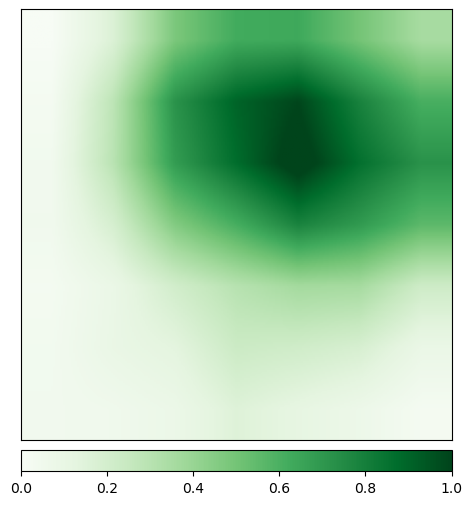

(<Figure size 600x600 with 2 Axes>, <Axes: >)

In [140]:
import torch
import torch.nn.functional as F

# 1. 기여도 계산 (이미 하신 부분)
# attributions shape: [1, 1, H_feat, W_feat] (보통 채널이 1로 축소되어 나옴)
attributions = gc.attribute(img.unsqueeze(0), target=target_idx)

# 2. [수정] interpolate 호출 방식 변경
# 텐서의 차원이 [Batch, Channel, H, W]인지 확인 필수 (4차원이어야 함)
if len(attributions.shape) == 3:
    attributions = attributions.unsqueeze(0)

# 직접 F.interpolate를 쓰거나 Captum의 함수를 정확히 호출
upsampled_attr = F.interpolate(attributions, size=(224, 224), mode='bilinear', align_corners=False)

# 3. 넘파이 변환 및 축 변경
# upsampled_attr: [1, 1, 224, 224] -> squeeze 후 [224, 224]
attr_np = upsampled_attr.squeeze().cpu().detach().numpy()

# 4. 시각화 코드 (입력 이미지 처리 주의)
# img가 이미 numpy이고 (224, 224, 3)이라면 np.transpose 불필요
# 만약 img가 (3, 224, 224) 텐서라면 아래와 같이 변환
img_np = img.permute(1, 2, 0).cpu().detach().numpy() if torch.is_tensor(img) else img

viz.visualize_image_attr(
    attr_np[:, :, np.newaxis], # [H, W, 1] 형태로 전달
    img_np,
    method="heat_map",
    sign="positive",
    show_colorbar=True
)